Run model using parameter combination found in model_testing.ipynb

In [ ]:
import os
import pandas as pd
from BERTopic_model import run_BERTopic_model

# Dataloading
df = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "data", "data_advice_fulltext.csv"))
docs = list(df["text"])
docs = [doc.replace('\xa0', '') for doc in docs]
classes = list(df["gen"])

base_param_dic = {
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "n_neighbors": 15,
    "n_components": 10,
    "min_dist": 0.0,
    "min_cluster_size": 20,
    "min_df": 3,
    "max_df": 1.0,
    "ngram_range": (1, 3),
    "top_n_words": 5,
    "seed": 0
}

topic_model = run_BERTopic_model(base_param_dic, docs)
topic_model.get_topic_info()

In [ ]:

base_param_dic = {
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "n_neighbors": 15,
    "n_components": 10,
    "min_dist": 0.0,
    "min_cluster_size": 20,
    "min_df": 3,
    "max_df": 1.0,
    "ngram_range": (1, 3),
    "top_n_words": 5,
    "seed": 0
}

topic_model = run_BERTopic_model(base_param_dic, docs)
topic_model.get_topic_info()

Save model for later use

In [ ]:
topic_model.save(os.path.join(os.path.dirname(os.getcwd()), "results", "BERTopic_model"), serialization="safetensors", save_ctfidf=True, save_embedding_model="all-MiniLM-L6-v2")

BERTopic visualization tools

In [ ]:
topic_model.visualize_barchart()

In [20]:
topic_model.visualize_documents(docs)

NameError: name 'topic_model' is not defined

In [ ]:
topics_over_time = topic_model.topics_over_time(docs, classes)
topic_model.visualize_topics_over_time(topics_over_time)

In [ ]:
topic_model.visualize_hierarchy()

In [ ]:
topic_model.visualize_topics()

## STATS

In [ ]:
topic_distr, _ = topic_model.approximate_distribution(docs)
df_stat = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "data", "data_stake.csv"))

for topic_n in range(len(topic_distr[0,:])):
    topic_name = "topic_" + str(topic_n)
    df_stat[topic_name] = topic_distr[:, topic_n]

df_stat["assigned_topic"] = topic_model.topics_

In [ ]:
parent_topic_weight = []
var_names = [f'topic_{n}' for n in range(len(topic_distr[0, :]))]

for i in range(len(df_stat["ID"])):
    parent_ID = df_stat["parent_ID"][i]
    parent_row = df_stat[df_stat["ID"] == parent_ID]
    if len(parent_row) < 1:
        parent_topic_weight.append([None for n in range(len(topic_distr[0, :]))])
    else:
        res = parent_row[var_names].values.tolist()
        parent_topic_weight.append(res[0])

parent_topic_df = pd.DataFrame(parent_topic_weight)
parent_topic_df.columns = [f'parent_topic_{n}' for n in range(len(topic_distr[0, :]))]

df_stat = pd.concat([df_stat, parent_topic_df], axis=1)
df_stat = df_stat.loc[:, ~df_stat.columns.str.contains('^Unnamed')]
df_stat.tail(2)

In [ ]:
var_names = ["score_corrected", "pl2_understanding", "pl1_understanding"] + [f'topic_{n}' for n in range(len(topic_distr[0, :]))] + [f'parent_topic_{n}' for n in range(len(topic_distr[0, :]))]

cor_table = df_stat[var_names].corr()
cor_table

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cor_table, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap')
plt.show()

Output

In [ ]:
df_stat.to_csv(os.path.join(os.path.dirname(os.getcwd()), "results", "docs_topic_weights.csv"), header=True, index=False)

Reduced outliers

In [17]:
import os
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", use_auth_token=False)
topic_model_reduce = BERTopic.load(os.path.join(os.path.dirname(os.getcwd()), "results", "BERTopic_model"), embedding_model=embedding_model)
topic_model_reduce.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,MMR,Representative_Docs
0,-1,182,-1_gnome_gnomes_mushrooms_points,"[gnome, gnomes, mushrooms, points, try]","[gnomes, gnome, colors, colours, colour, color...","[gnome, colors, number mushrooms, red, yellow,...",NaN
1,0,194,0_gnome_points_gnomes_colour,"[gnome, points, gnomes, colour, hat]","[points gnomes, gnomes points, colour gnomes, ...","[points gnomes, gnomes points, colour gnome, g...",NaN
2,1,146,1_mushrooms_gnome_gnomes_colour,"[mushrooms, gnome, gnomes, colour, try]","[gnome mushrooms, gnomes mushrooms, colour gno...","[gnome mushrooms, gnomes mushrooms, colour gno...",NaN
3,2,144,2_basket_red_yellow_mushrooms,"[basket, red, yellow, mushrooms, gnomes]","[gnomes yellow basket, gnomes red basket, bask...","[gnomes yellow basket, gnomes red basket, bask...",NaN
4,3,100,3_points_blue_colours_pink,"[points, blue, colours, pink, purple]","[certain colours, pick colour, colours, colors...","[certain colours, pick colour, colors, blue gr...",NaN
5,4,77,4_basket_red_baskets_yellow,"[basket, red, baskets, yellow, points]","[gnomes baskets, basket colours, colour basket...","[gnomes baskets, basket colours, baskets red y...",NaN
6,5,73,5_mushrooms_colours_mushroom_gives,"[mushrooms, colours, mushroom, gives, change]","[colour gives mushrooms, colours mushrooms, mu...","[colour gives mushrooms, colours mushrooms, mu...",NaN
7,6,34,6_hats_tall_hat_taller,"[hats, tall, hat, taller, tall hats]","[hat colour, short yellow hat, tall hats, shor...","[hat colour, short yellow hat, tall hats, shor...",NaN
8,7,26,7_keys_fingers_just_breaks,"[keys, fingers, just, breaks, make]","[fingers keys, stay focused, keyboard, distrac...","[fingers keys, stay focused, keyboard, distrac...",NaN
9,8,24,8_forest_mushrooms_green_gnomes,"[forest, mushrooms, green, gnomes, blue]","[mushrooms gnomes, mushrooms forest, number mu...","[mushrooms gnomes, mushrooms forest, number mu...",NaN


In [ ]:
from evaluation import evaluate_model

topics = topic_model_reduce.topics_
embeddings = embedding_model.encode(docs, show_progress_bar=True)

new_topics = topic_model_reduce.reduce_outliers(docs, topics, strategy="c-tf-idf", probabilities=0.2)
topic_model_reduce.update_topics(docs, topics=new_topics)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

2025-03-03 17:17:27,483 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [23]:
topic_model_reduce.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,MMR,Representative_Docs
0,0,249,0_the_to_gnome_and,"[the, to, gnome, and, gnomes, you, points, of,...","[points gnomes, gnomes points, colour gnomes, ...","[points gnomes, gnomes points, colour gnome, g...",NaN
1,1,189,1_the_to_mushrooms_of,"[the, to, mushrooms, of, you, and, gnome, gnom...","[gnome mushrooms, gnomes mushrooms, colour gno...","[gnome mushrooms, gnomes mushrooms, colour gno...",NaN
2,2,154,2_basket_the_to_red,"[basket, the, to, red, yellow, you, and, mushr...","[gnomes yellow basket, gnomes red basket, bask...","[gnomes yellow basket, gnomes red basket, bask...",NaN
3,3,121,3_the_and_to_it,"[the, and, to, it, you, points, that, blue, fo...","[certain colours, pick colour, colours, colors...","[certain colours, pick colour, colors, blue gr...",NaN
4,4,83,4_the_basket_to_and,"[the, basket, to, and, red, yellow, gnomes, yo...","[gnomes baskets, basket colours, colour basket...","[gnomes baskets, basket colours, baskets red y...",NaN
5,5,87,5_the_to_mushrooms_you,"[the, to, mushrooms, you, and, it, of, that, c...","[colour gives mushrooms, colours mushrooms, mu...","[colour gives mushrooms, colours mushrooms, mu...",NaN
6,6,42,6_the_hats_hat_and,"[the, hats, hat, and, tall, to, for, you, if, of]","[hat colour, short yellow hat, tall hats, shor...","[hat colour, short yellow hat, tall hats, shor...",NaN
7,7,46,7_the_you_to_your,"[the, you, to, your, and, as, on, it, of, make]","[fingers keys, stay focused, keyboard, distrac...","[fingers keys, stay focused, keyboard, distrac...",NaN
8,8,29,8_forest_to_the_you,"[forest, to, the, you, mushrooms, other, the o...","[mushrooms gnomes, mushrooms forest, number mu...","[mushrooms gnomes, mushrooms forest, number mu...",NaN


In [21]:
topic_model_reduce.visualize_barchart()

In [22]:
topic_model_reduce.visualize_documents(docs)

In [24]:
topics_over_time = topic_model_reduce.topics_over_time(docs, classes)
topic_model_reduce.visualize_topics_over_time(topics_over_time)

10it [00:01,  6.11it/s]


In [25]:
topic_model_reduce.visualize_hierarchy()

In [26]:
topic_model_reduce.visualize_topics()

In [27]:
topic_distr, _ = topic_model_reduce.approximate_distribution(docs)
df_stat = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "data", "data_stake.csv"))

for topic_n in range(len(topic_distr[0,:])):
    topic_name = "topic_" + str(topic_n)
    df_stat[topic_name] = topic_distr[:, topic_n]

df_stat["assigned_topic"] = topic_model_reduce.topics_

parent_topic_weight = []
var_names = [f'topic_{n}' for n in range(len(topic_distr[0, :]))]

for i in range(len(df_stat["ID"])):
    parent_ID = df_stat["parent_ID"][i]
    parent_row = df_stat[df_stat["ID"] == parent_ID]
    if len(parent_row) < 1:
        parent_topic_weight.append([None for n in range(len(topic_distr[0, :]))])
    else:
        res = parent_row[var_names].values.tolist()
        parent_topic_weight.append(res[0])

parent_topic_df = pd.DataFrame(parent_topic_weight)
parent_topic_df.columns = [f'parent_topic_{n}' for n in range(len(topic_distr[0, :]))]

df_stat = pd.concat([df_stat, parent_topic_df], axis=1)
df_stat = df_stat.loc[:, ~df_stat.columns.str.contains('^Unnamed')]
df_stat.tail(2)

var_names = ["score_corrected", "pl2_understanding", "pl1_understanding"] + [f'topic_{n}' for n in range(len(topic_distr[0, :]))] + [f'parent_topic_{n}' for n in range(len(topic_distr[0, :]))]

cor_table = df_stat[var_names].corr()
cor_table

100%|██████████| 1/1 [00:00<00:00,  1.39it/s]


,score_corrected,pl2_understanding,pl1_understanding,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,...,topic_8,parent_topic_0,parent_topic_1,parent_topic_2,parent_topic_3,parent_topic_4,parent_topic_5,parent_topic_6,parent_topic_7,parent_topic_8
score_corrected,1.000000,0.455890,0.164747,-0.141444,-0.090683,0.330015,-0.004248,0.229796,-0.039726,-0.102137,...,0.223323,-0.097876,-0.084514,0.282548,0.052310,0.214217,-0.078466,-0.105310,-0.129054,0.192593
pl2_understanding,0.455890,1.000000,0.042760,-0.221813,-0.189453,0.559640,-0.066483,0.454660,-0.108563,-0.108361,...,0.233630,-0.188340,-0.174075,0.492096,0.014746,0.390063,-0.114989,-0.121784,-0.137389,0.191714
pl1_understanding,0.164747,0.042760,1.000000,0.000795,0.074920,0.059143,0.081827,0.045303,0.018368,-0.045441,...,0.015094,0.069158,0.101782,-0.058339,0.009364,-0.031925,0.087071,-0.062660,-0.063919,-0.081007
topic_0,-0.141444,-0.221813,0.000795,1.000000,0.123191,-0.302087,-0.101454,-0.062634,-0.108823,-0.023266,...,-0.207432,0.235208,0.125982,-0.156738,-0.072996,-0.069704,0.009833,0.031850,-0.050850,-0.114542
topic_1,-0.090683,-0.189453,0.074920,0.123191,1.000000,-0.192919,-0.269477,-0.250307,0.229599,-0.134249,...,-0.012384,0.081865,0.296597,-0.166257,-0.140898,-0.187142,0.150728,-0.015192,-0.093971,-0.032391
topic_2,0.330015,0.559640,0.059143,-0.302087,-0.192919,1.000000,-0.020683,0.739756,-0.162773,-0.199457,...,0.169641,-0.201760,-0.183770,0.547141,0.091681,0.436653,-0.149814,-0.152420,-0.129602,0.095915
topic_3,-0.004248,-0.066483,0.081827,-0.101454,-0.269477,-0.020683,1.000000,-0.040152,-0.149011,-0.092315,...,-0.060777,-0.027340,-0.103360,-0.001404,0.242372,-0.020712,-0.047477,-0.004247,-0.049090,0.030935
topic_4,0.229796,0.454660,0.045303,-0.062634,-0.250307,0.739756,-0.040152,1.000000,-0.241023,-0.154719,...,0.016612,-0.131759,-0.188012,0.459522,0.041649,0.422553,-0.143290,-0.122674,-0.090867,0.010347
topic_5,-0.039726,-0.108563,0.018368,-0.108823,0.229599,-0.162773,-0.149011,-0.241023,1.000000,-0.125021,...,-0.015012,0.036321,0.122637,-0.110779,-0.047313,-0.109006,0.272878,-0.073736,-0.054472,-0.003754
topic_6,-0.102137,-0.108361,-0.045441,-0.023266,-0.134249,-0.199457,-0.092315,-0.154719,-0.125021,1.000000,...,-0.133508,0.063437,-0.078876,-0.112563,-0.044816,-0.085504,-0.111405,0.439218,-0.036262,-0.096025


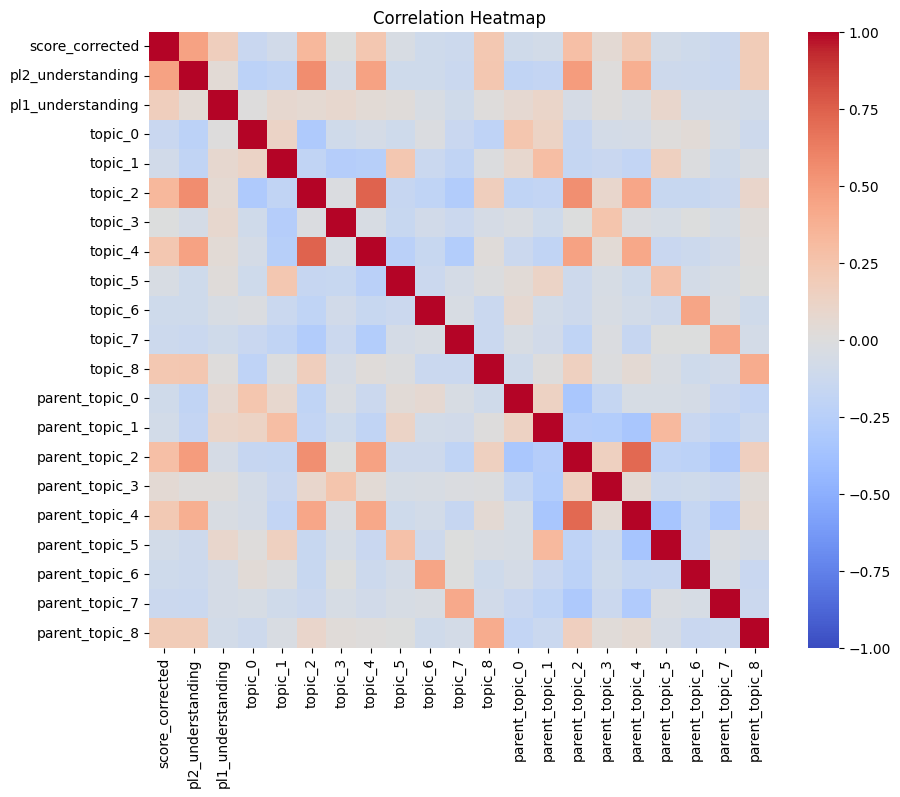

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cor_table, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap')
plt.show()

In [29]:
df_stat.to_csv(os.path.join(os.path.dirname(os.getcwd()), "results", "docs_topic_weights_reduce_outlier.csv"), header=True, index=False)